<a href="https://colab.research.google.com/github/maisasq123/lia1_2026_2/blob/main/Entregas%20-%20Ma%C3%ADsa%20Queiroz/Projeto%202/Projeto_2_Ma%C3%ADsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Projeto Ponta a Ponta — Classificação de Flores com Inteligência Artificial

### 🌺 Reconhecimento automático de 102 espécies de flores utilizando Redes Neurais Convolucionais

> **“Uma imagem, 102 possibilidades. Será que a IA consegue descobrir qual é a flor?”** 🌱🤖


### 🎯 Objetivo

Construir um modelo de **Inteligência Artificial** capaz de analisar uma fotografia de uma flor e classificá-la entre **102 categorias diferentes**, utilizando uma **Rede Neural Convolucional (CNN)**.

O projeto percorre todas as principais etapas de um pipeline de Inteligência Artificial:

### 🧠 Pipeline

**Dados → Exploração → Pré-processamento → Modelo → Treinamento → Validação → Teste → Avaliação → Inferência**

> 💡 **A proposta:** aplicar o mesmo pipeline apresentado nos notebooks da disciplina a um problema diferente de classificação de imagens.

## 🌷 1. Dataset — Oxford Flowers 102

O **Oxford Flowers 102** é um dataset público de imagens de flores, utilizado em tarefas de **classificação multiclasse**.

Possui **102 categorias**, com imagens variadas em iluminação, posição, formato e aparência.

### 🌺 Características

| Característica | Descrição |
|---|---|
| 🌸 Categorias | **102 espécies** |
| 📸 Dados | **Imagens coloridas** |
| 🎯 Problema | **Classificação multiclasse** |
| 🧠 Modelo | **CNN** |
| 🔬 Área | **Visão Computacional** |

> 💡 **Desafio:** ensinar a IA a reconhecer flores a partir de suas características visuais.

## 📚 2. Bibliotecas

Nesta etapa serão importadas as bibliotecas necessárias para carregar, manipular, visualizar e modelar os dados.

- **TensorFlow:** construção e treinamento da rede neural.
- **TensorFlow Datasets:** acesso ao Oxford Flowers 102.
- **NumPy:** manipulação numérica dos dados.
- **Matplotlib:** visualização das imagens e dos resultados.
- **Scikit-learn:** geração de métricas e matriz de confusão.

### 💻 IMPORTAÇÃO

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("TensorFlow Datasets carregado com sucesso! 🌸")
print("Bibliotecas carregadas com sucesso! ✅")

TensorFlow: 2.20.0
TensorFlow Datasets carregado com sucesso! 🌸
Bibliotecas carregadas com sucesso! ✅


## 🌱 3. Carregamento dos Dados

Os dados serão carregados pelo **TensorFlow Datasets (TFDS)** e divididos em **treinamento, validação e teste**.

> 💡 Essa divisão permite avaliar se o modelo consegue **generalizar para imagens que não viu durante o treinamento**.

In [2]:
# 🌸 Carregando o Oxford Flowers 102

(dataset_treino, dataset_validacao, dataset_teste), info = tfds.load(
    "oxford_flowers102",
    split=["train", "validation", "test"],
    as_supervised=True,
    with_info=True
)

print("🌷 Dataset carregado com sucesso!")
print()
print("🖼️ Imagens de treinamento:", info.splits["train"].num_examples)
print("🔍 Imagens de validação:", info.splits["validation"].num_examples)
print("🧪 Imagens de teste:", info.splits["test"].num_examples)
print("📚 Número de classes:", info.features["label"].num_classes)

🌷 Dataset carregado com sucesso!

🖼️ Imagens de treinamento: 1020
🔍 Imagens de validação: 1020
🧪 Imagens de teste: 6149
📚 Número de classes: 102


## 🌷 4. Tradução das Classes

As classes do dataset estão originalmente em inglês. Para facilitar a interpretação, seus nomes serão apresentados em **português**.

> 💡 A tradução é usada apenas na **visualização**. Os rótulos e índices originais permanecem inalterados.

In [3]:
# 🌷 Tradução dos nomes das classes para português

nomes_originais = info.features["label"].names

nomes_portugues = [
    "Prímula-rosa",
    "Orquídea-de-folhas-duras",
    "Campânulas-de-Cantuária",
    "Ervilha-de-cheiro",
    "Calêndula-inglesa",
    "Lírio-tigre",
    "Orquídea-da-lua",
    "Ave-do-paraíso",
    "Acônito",
    "Cardo-globo",
    "Boca-de-leão",
    "Tussilagem",
    "Protea-rei",
    "Cardo-lança",
    "Íris-amarela",
    "Flor-globo",
    "Equinácea-púrpura",
    "Lírio-peruano",
    "Flor-balão",
    "Arum-branco-gigante",
    "Lírio-de-fogo",
    "Flor-alfinete",
    "Fritilária",
    "Gengibre-vermelho",
    "Jacinto-uva",
    "Papoula-do-milho",
    "Plumas-do-Príncipe de Gales",
    "Genciana-sem-caule",
    "Alcachofra",
    "Cravo-do-poeta",
    "Cravo",
    "Flox-de-jardim",
    "Nigela",
    "Áster-mexicano",
    "Cardo-marinho-alpino",
    "Cattleya-de-lábios-rubi",
    "Flor-do-Cabo",
    "Astrância-maior",
    "Tulipa-do-Sião",
    "Rosa-de-quaresma",
    "Margarida-de-Barberton",
    "Narciso",
    "Gladíolo",
    "Poinsétia",
    "Bolero Deep Blue",
    "Goivo",
    "Tagete",
    "Botão-de-ouro",
    "Margarida-olho-de-boi",
    "Dente-de-leão-comum",
    "Petúnia",
    "Amor-perfeito-silvestre",
    "Prímula",
    "Girassol",
    "Pelargônio",
    "Dália Bishop of Llandaff",
    "Gaura",
    "Gerânio",
    "Dália-laranja",
    "Dália rosa-amarela",
    "Cautleya spicata",
    "Anêmona-japonesa",
    "Rudbéquia",
    "Arbusto-prateado",
    "Papoula-da-Califórnia",
    "Margarida-africana",
    "Açafrão-de-primavera",
    "Íris-barbada",
    "Anêmona",
    "Papoula-arbórea",
    "Gazânia",
    "Azaleia",
    "Lírio-d'água",
    "Rosa",
    "Estramônio",
    "Glória-da-manhã",
    "Flor-da-paixão",
    "Lótus",
    "Lírio-sapo",
    "Antúrio",
    "Frangipani",
    "Clemátis",
    "Hibisco",
    "Columbina",
    "Rosa-do-deserto",
    "Malva-arbórea",
    "Magnólia",
    "Ciclame",
    "Agrião",
    "Cana-da-índia",
    "Hippeastrum",
    "Erva-cidreira",
    "Musgo-bola",
    "Dedaleira",
    "Bougainvillea",
    "Camélia",
    "Malva",
    "Petúnia-mexicana",
    "Bromélia",
    "Margarida-cobertor",
    "Jasmim-da-Virgínia",
    "Lírio-amora"
]

# Criando a relação entre o nome original e o nome em português
traducao_classes = dict(zip(nomes_originais, nomes_portugues))

print("🌷 Tradução das classes criada com sucesso!")
print(f"📚 Classes traduzidas: {len(traducao_classes)}")

🌷 Tradução das classes criada com sucesso!
📚 Classes traduzidas: 102


In [4]:
# 🔎 Conferindo a tradução

for i in range(10):
    print(f"{i:02d} | {nomes_originais[i]} → {nomes_portugues[i]}")

00 | pink primrose → Prímula-rosa
01 | hard-leaved pocket orchid → Orquídea-de-folhas-duras
02 | canterbury bells → Campânulas-de-Cantuária
03 | sweet pea → Ervilha-de-cheiro
04 | english marigold → Calêndula-inglesa
05 | tiger lily → Lírio-tigre
06 | moon orchid → Orquídea-da-lua
07 | bird of paradise → Ave-do-paraíso
08 | monkshood → Acônito
09 | globe thistle → Cardo-globo


## 🔎 5. Conhecendo os Dados

Antes de construir o modelo, é importante observar como os dados estão estruturados.

Cada exemplo possui:

- 🖼️ uma imagem;
- 🏷️ um rótulo correspondente à categoria da flor.

Como estamos trabalhando com **102 classes**, o modelo terá 102 possíveis respostas para cada imagem.

In [5]:
# 🔎 Conhecendo as classes do dataset

print("🌸 Oxford Flowers 102")
print("-" * 45)

print(f"📚 Quantidade de classes: {len(nomes_portugues)}")

print("\n🏷️ Primeiras 20 classes:")

for i in range(20):
    print(f"{i:02d} | {nomes_portugues[i]}")

🌸 Oxford Flowers 102
---------------------------------------------
📚 Quantidade de classes: 102

🏷️ Primeiras 20 classes:
00 | Prímula-rosa
01 | Orquídea-de-folhas-duras
02 | Campânulas-de-Cantuária
03 | Ervilha-de-cheiro
04 | Calêndula-inglesa
05 | Lírio-tigre
06 | Orquídea-da-lua
07 | Ave-do-paraíso
08 | Acônito
09 | Cardo-globo
10 | Boca-de-leão
11 | Tussilagem
12 | Protea-rei
13 | Cardo-lança
14 | Íris-amarela
15 | Flor-globo
16 | Equinácea-púrpura
17 | Lírio-peruano
18 | Flor-balão
19 | Arum-branco-gigante


## 🌺 5. Visualização das Imagens

Antes do treinamento, vamos observar alguns exemplos do dataset e suas variações de **cor, formato, orientação, iluminação e enquadramento**.

> 💡 Essas características ajudam a rede neural a aprender **padrões visuais para a classificação**.

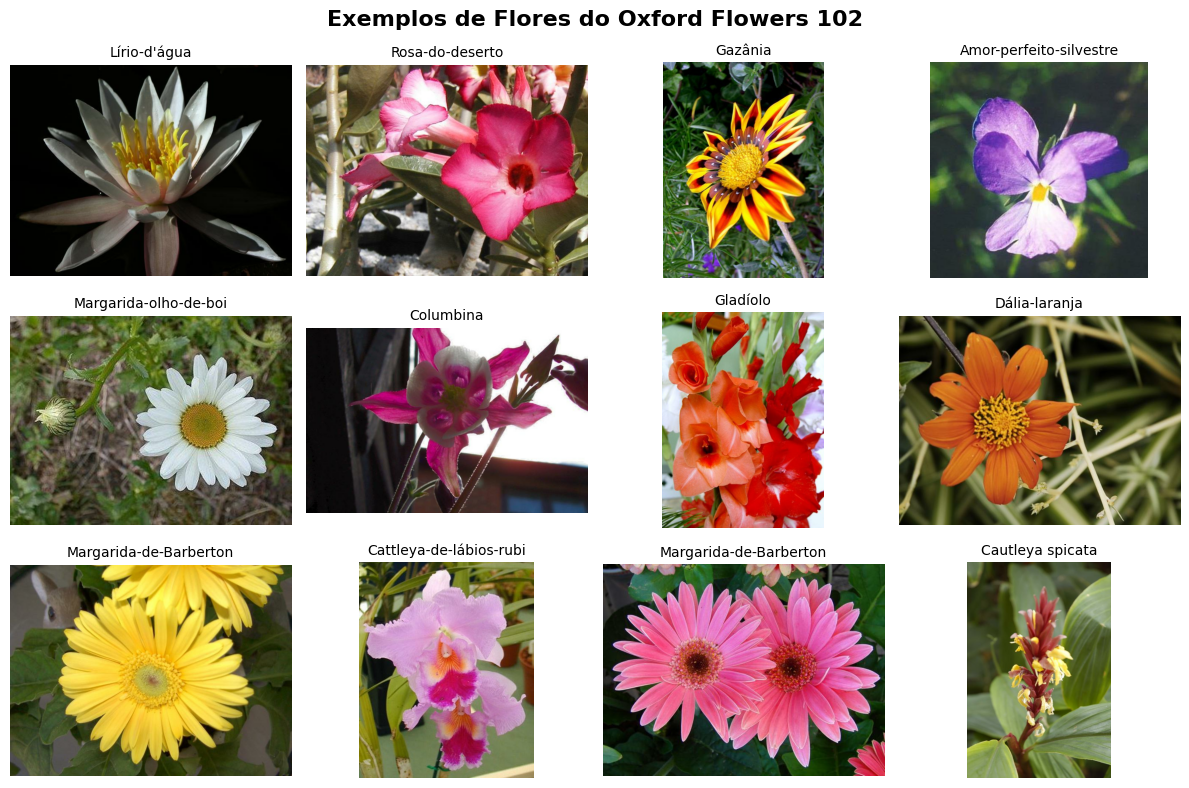

In [7]:
# 🌸 Visualizando exemplos do dataset

plt.figure(figsize=(12, 8))

for i, (imagem, label) in enumerate(dataset_treino.take(12)):
    plt.subplot(3, 4, i + 1)

    plt.imshow(imagem)
    plt.title(nomes_portugues[label.numpy()], fontsize=10)
    plt.axis("off")

plt.suptitle(
    "Exemplos de Flores do Oxford Flowers 102",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 🧹 7. Pré-processamento

As imagens possuem dimensões variadas. Para padronizá-las, todas serão redimensionadas para **128 × 128 pixels**, mantendo os **3 canais RGB**.

Também será feita a **normalização dos pixels**, convertendo:

**0–255 → 0–1**

> 💡 A normalização coloca os dados em uma escala adequada, contribuindo para um **treinamento mais estável**.

In [8]:
# 🧹 Preparando as imagens para a rede neural

IMG_SIZE = (128, 128)
BATCH_SIZE = 32


def preparar_imagem(imagem, label):
    # Redimensiona todas as imagens para 128 × 128
    imagem = tf.image.resize(imagem, IMG_SIZE)

    # Converte os pixels para float e normaliza para 0–1
    imagem = tf.cast(imagem, tf.float32) / 255.0

    return imagem, label


# Aplicando o pré-processamento
dataset_treino = dataset_treino.map(
    preparar_imagem,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_validacao = dataset_validacao.map(
    preparar_imagem,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_teste = dataset_teste.map(
    preparar_imagem,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Organizando os dados em lotes
dataset_treino = (
    dataset_treino
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_validacao = (
    dataset_validacao
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_teste = (
    dataset_teste
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pré-processamento concluído! ✅")
print(f"📐 Tamanho das imagens: {IMG_SIZE[0]} × {IMG_SIZE[1]} × 3")
print(f"📦 Tamanho do lote: {BATCH_SIZE}")

Pré-processamento concluído! ✅
📐 Tamanho das imagens: 128 × 128 × 3
📦 Tamanho do lote: 32


## 🔍 7.1 Verificando o formato

Após o pré-processamento, vamos verificar o formato de uma imagem e confirmar que os valores dos pixels estão dentro da escala esperada.

In [9]:
imagem_exemplo, label_exemplo = next(iter(dataset_treino))

print("Formato das imagens:", imagem_exemplo.shape)
print("Valor mínimo:", tf.reduce_min(imagem_exemplo).numpy())
print("Valor máximo:", tf.reduce_max(imagem_exemplo).numpy())

Formato das imagens: (32, 128, 128, 3)
Valor mínimo: 0.0
Valor máximo: 1.0


## 🔄 8. Data Augmentation

Para aumentar a variedade dos dados e melhorar a **generalização**, serão aplicadas pequenas transformações durante o treinamento:

- 🔄 Inversão horizontal
- 🔍 Zoom
- ↪️ Rotação

> 💡 O objetivo é tornar o modelo mais **robusto a diferentes posições e enquadramentos**.

In [10]:
# 🔄 Criando as transformações para aumento de dados

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.1)
])

print("Data Augmentation configurado! 🔄")

Data Augmentation configurado! 🔄


## 🌸 8.1 Visualizando as transformações

Vamos observar como uma mesma imagem pode sofrer pequenas alterações durante o treinamento.

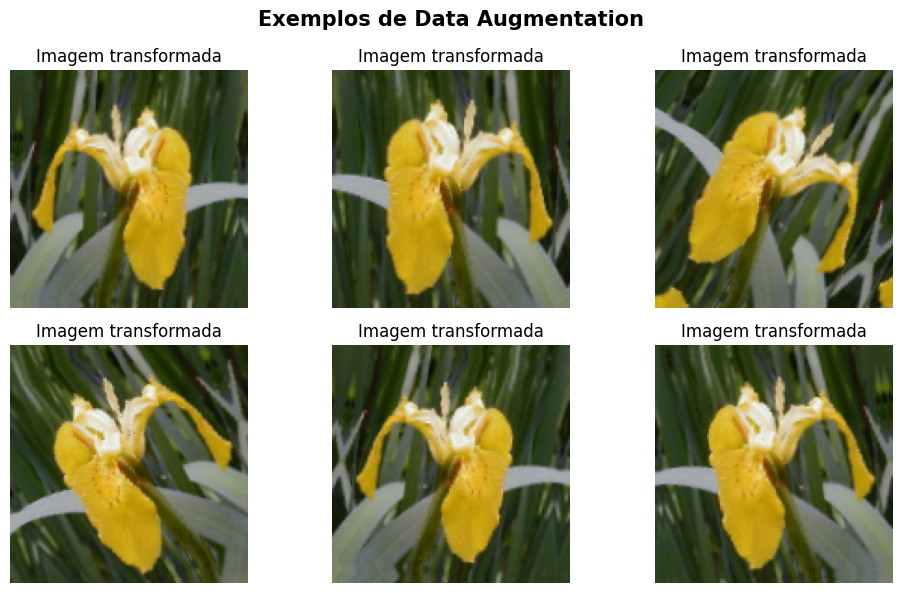

In [11]:
# 🌸 Visualizando as transformações

imagem, label = next(iter(dataset_treino))
imagem = imagem[0]

plt.figure(figsize=(10, 6))

for i in range(6):
    imagem_transformada = data_augmentation(
        tf.expand_dims(imagem, axis=0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(imagem_transformada)
    plt.title("Imagem transformada")
    plt.axis("off")

plt.suptitle(
    "Exemplos de Data Augmentation",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 🧠 9. Construção da Rede Neural Convolucional

A **Rede Neural Convolucional (CNN)** aprende padrões visuais como **bordas, formas e texturas**, sendo adequada para classificação de imagens.

Neste projeto, utilizaremos **três blocos convolucionais**, com filtros crescentes de **32 → 64 → 128**, além de **Data Augmentation** e **Dropout** para melhorar a generalização.

A **GlobalAveragePooling2D** resume as características extraídas, e a camada final possui **102 neurônios**, um para cada categoria. A **Softmax** gera as probabilidades das classes.

### 🏗️ Arquitetura

**Imagem → Augmentation → Conv → Pooling → Conv → Pooling → Conv → Pooling → Global Average Pooling → Dense → Dropout → Softmax**

In [13]:
# 🧠 Construindo a Rede Neural Convolucional

modelo = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Aumento de dados
    data_augmentation,

    # Bloco convolucional 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Bloco convolucional 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Bloco convolucional 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Redução dos mapas de características
    layers.GlobalAveragePooling2D(),

    # Classificação
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # 102 classes
    layers.Dense(102, activation="softmax")
])

modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 102)            │        13,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,918 (480.15 KB)

 Trainable params: 122,918 (480.15 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ 10. Compilação do Modelo

Antes do treinamento, definimos como a rede irá aprender:

- **Otimizador:** Adam
- **Função de perda:** Sparse Categorical Crossentropy
- **Métrica:** Acurácia

> 💡 Com essas configurações, o modelo está pronto para o **treinamento**.

In [14]:
# ⚙️ Compilando o modelo

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado com sucesso! ✅")

Modelo compilado com sucesso! ✅


# 🚀 11. Treinamento

O modelo será treinado com as imagens de **treinamento**, enquanto o conjunto de **validação** acompanhará seu desempenho em dados não utilizados no ajuste dos pesos.

Durante o processo, serão observadas a **acurácia** e a **função de perda**.

> 💡 A validação ajuda a verificar se o modelo está **aprendendo e generalizando**.

In [16]:
%%time

# 🛡️ Controle de overfitting durante o treinamento

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = modelo.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=30,
    callbacks=[early_stopping]
)

print("Treinamento concluído! 🎉")

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 797ms/step - accuracy: 0.0814 - loss: 3.6759 - val_accuracy: 0.1284 - val_loss: 3.6532
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 821ms/step - accuracy: 0.1108 - loss: 3.5592 - val_accuracy: 0.1235 - val_loss: 3.6145
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 928ms/step - accuracy: 0.1088 - loss: 3.5389 - val_accuracy: 0.1333 - val_loss: 3.5877
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 807ms/step - accuracy: 0.1186 - loss: 3.4603 - val_accuracy: 0.1549 - val_loss: 3.5024
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 945ms/step - accuracy: 0.1235 - loss: 3.3752 - val_accuracy: 0.1559 - val_loss: 3.5048
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 935ms/step - accuracy: 0.1412 - loss: 3.3466 - val_accuracy: 0.1647 - val_loss: 3.4362
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 801ms/step - accuracy: 0.1529 - loss: 3.2870 - val_accuracy: 0.1598 - val_loss: 3.4192
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 817ms/step - accuracy: 0.1539 - loss: 3.2083 - val_accu

## 📈 12. Analisando o Treinamento

As curvas mostram a evolução do modelo durante as épocas.

- 📈 **Acurácia:** classificações corretas.
- 📉 **Loss:** erro do modelo.

> 💡 A comparação entre treinamento e validação ajuda a identificar **overfitting**.

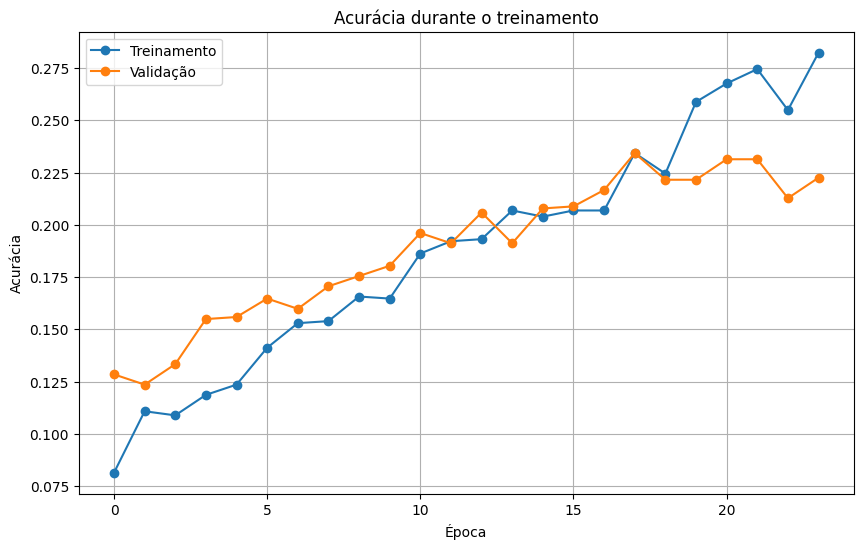

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], marker="o", label="Treinamento")
plt.plot(history.history["val_accuracy"], marker="o", label="Validação")

plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

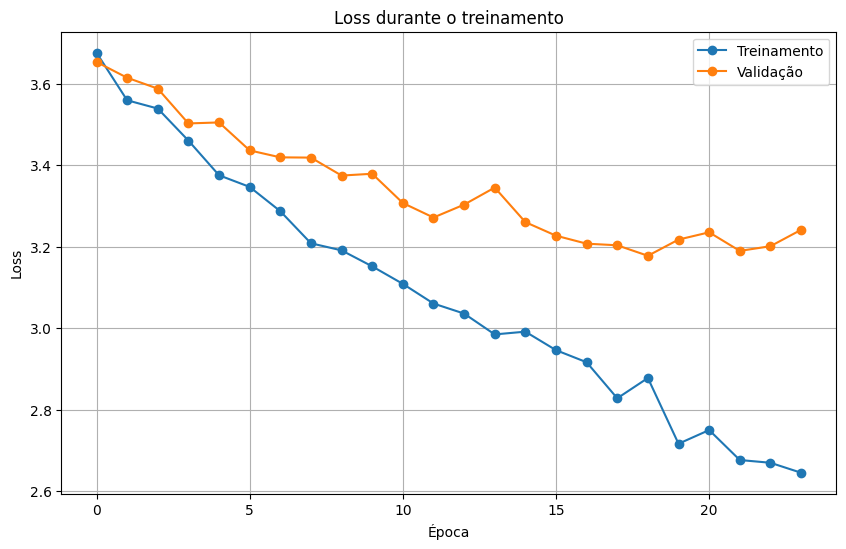

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], marker="o", label="Treinamento")
plt.plot(history.history["val_loss"], marker="o", label="Validação")

plt.title("Loss durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 🧪 13. Avaliação no Conjunto de Teste

O conjunto de teste permite realizar a **avaliação final** do modelo em imagens que não participaram do treinamento.

**Loss:** 3,3286  
**Acurácia:** 19,39%

> 💡 Com 102 classes, o acaso teria cerca de **0,98%** de acurácia. O resultado indica que o modelo **aprendeu padrões visuais úteis** para a classificação.

In [20]:
test_loss, test_accuracy = modelo.evaluate(dataset_teste)

print()
print(f"📊 Loss no teste: {test_loss:.4f}")
print(f"🎯 Acurácia no teste: {test_accuracy:.2%}")

193/193 ━━━━━━━━━━━━━━━━━━━━ 38s 195ms/step - accuracy: 0.1939 - loss: 3.3286

📊 Loss no teste: 3.3286
🎯 Acurácia no teste: 19.39%


## 🧩 14. Matriz de Confusão

A **matriz de confusão** permite identificar quais classes o modelo acertou e errou.

- ✅ **Diagonal:** classificações corretas.
- ❌ **Fora da diagonal:** classificações incorretas.

> 💡 Com 102 classes, a matriz é extensa. Por isso, também analisaremos as **principais confusões**.

Previsões realizadas: 6149


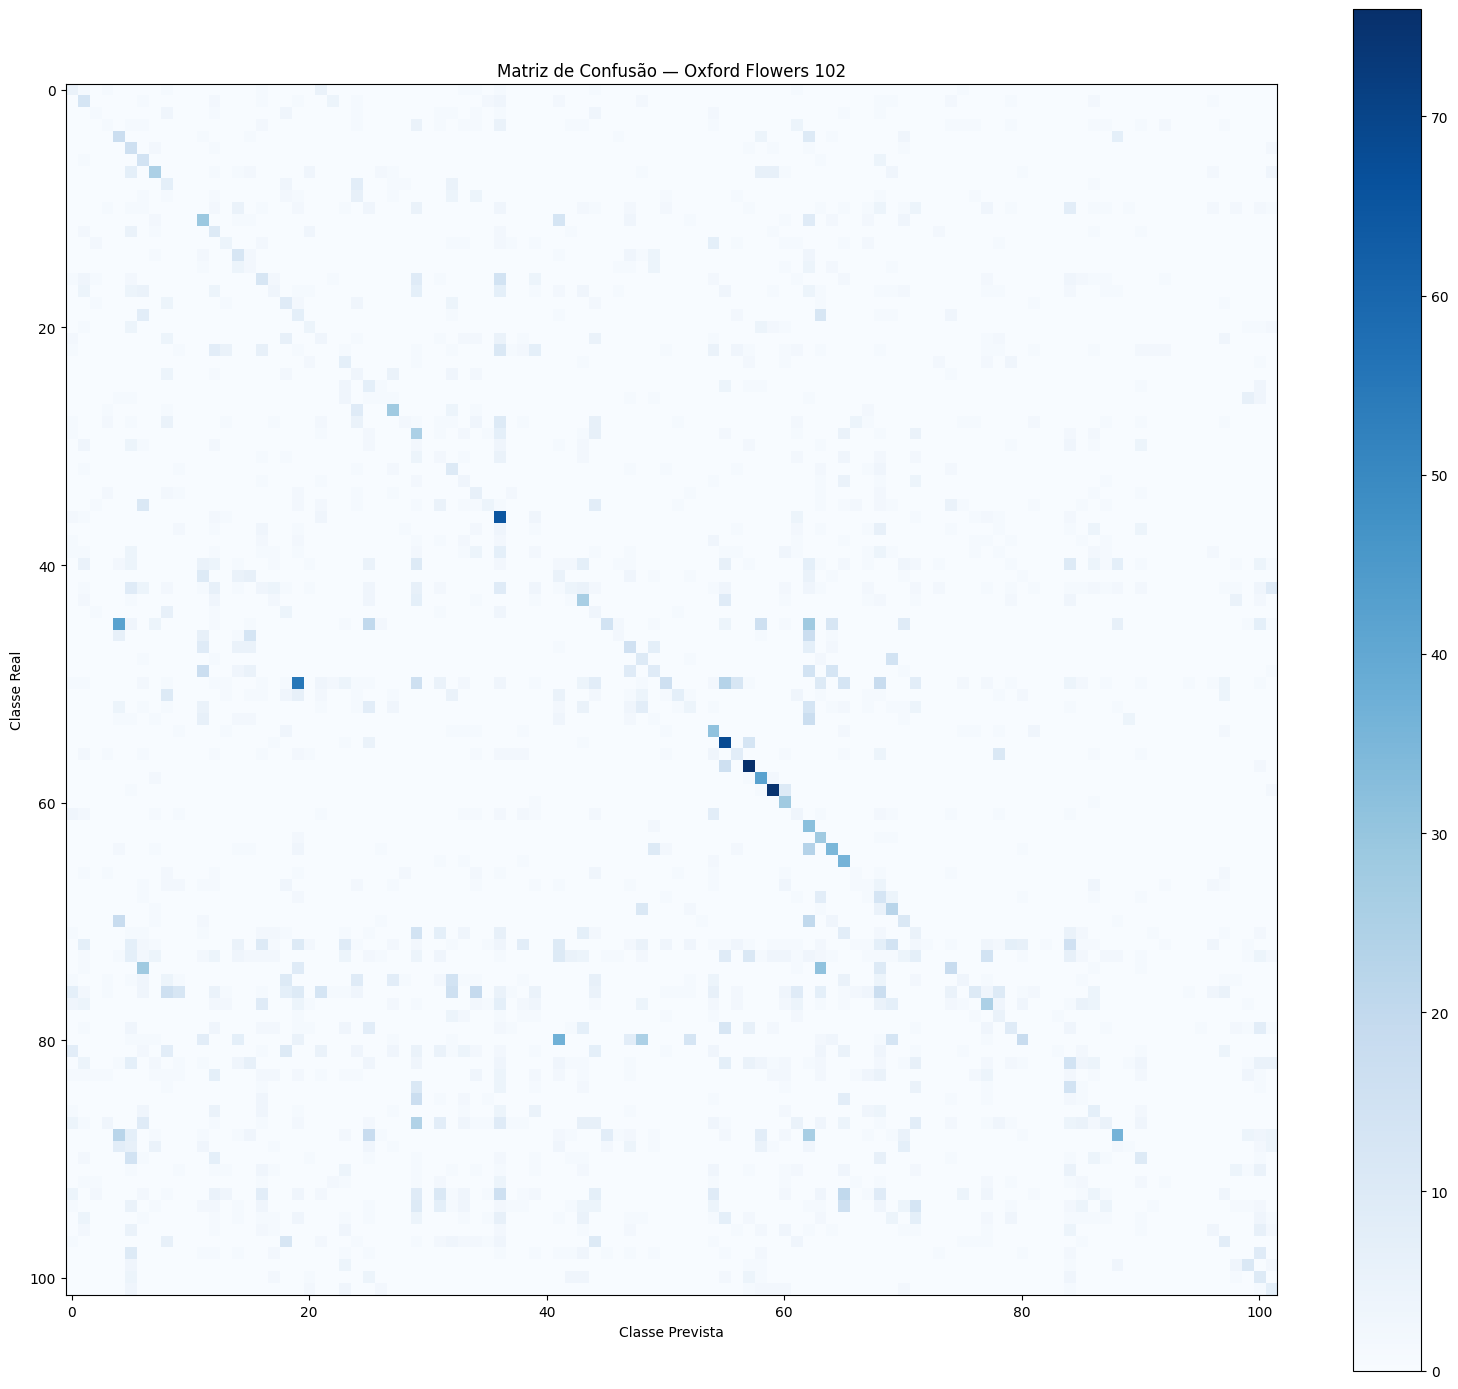

In [23]:
# 🧩 Gerando a matriz de confusão

y_true = []
y_pred = []

for imagens, labels in dataset_teste:
    previsoes = modelo.predict(imagens, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(previsoes, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Previsões realizadas:", len(y_pred))

matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))

plt.imshow(matriz, cmap="Blues")

plt.title("Matriz de Confusão — Oxford Flowers 102")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.colorbar()

plt.tight_layout()
plt.show()

## 🔎 15. Classes mais confundidas

Além da matriz de confusão, podemos identificar quais pares de classes apresentaram maior quantidade de erros.

Essa análise ajuda a entender quais espécies possuem características visuais semelhantes para o modelo.

In [24]:
# 🔍 Identificando as classes mais confundidas

confusoes = []

for classe_real in range(len(nomes_portugues)):
    for classe_prevista in range(len(nomes_portugues)):

        # Ignora a diagonal principal, que representa os acertos
        if classe_real != classe_prevista:
            quantidade = matriz[classe_real, classe_prevista]

            if quantidade > 0:
                confusoes.append(
                    (
                        quantidade,
                        classe_real,
                        classe_prevista
                    )
                )

# Ordenando da maior para a menor quantidade de erros
confusoes.sort(reverse=True)

print("🔍 Principais confusões do modelo:")
print("-" * 65)

for quantidade, classe_real, classe_prevista in confusoes[:10]:
    print(
        f"{quantidade:3d} vezes | "
        f"Real: {nomes_portugues[classe_real]} "
        f"→ Prevista: {nomes_portugues[classe_prevista]}"
    )

🔍 Principais confusões do modelo:
-----------------------------------------------------------------
 55 vezes | Real: Petúnia → Prevista: Arum-branco-gigante
 42 vezes | Real: Goivo → Prevista: Calêndula-inglesa
 37 vezes | Real: Frangipani → Prevista: Narciso
 31 vezes | Real: Estramônio → Prevista: Arbusto-prateado
 28 vezes | Real: Estramônio → Prevista: Orquídea-da-lua
 28 vezes | Real: Goivo → Prevista: Rudbéquia
 26 vezes | Real: Agrião → Prevista: Rudbéquia
 25 vezes | Real: Frangipani → Prevista: Margarida-olho-de-boi
 24 vezes | Real: Ciclame → Prevista: Cravo-do-poeta
 23 vezes | Real: Papoula-da-Califórnia → Prevista: Rudbéquia


## 🌸 10.1 Comparação visual das principais confusões

Para compreender melhor os erros do modelo, vamos comparar visualmente imagens pertencentes às classes que foram mais confundidas.

Em cada comparação, será apresentada uma imagem que o modelo classificou incorretamente ao lado de uma imagem representativa da classe que foi prevista.

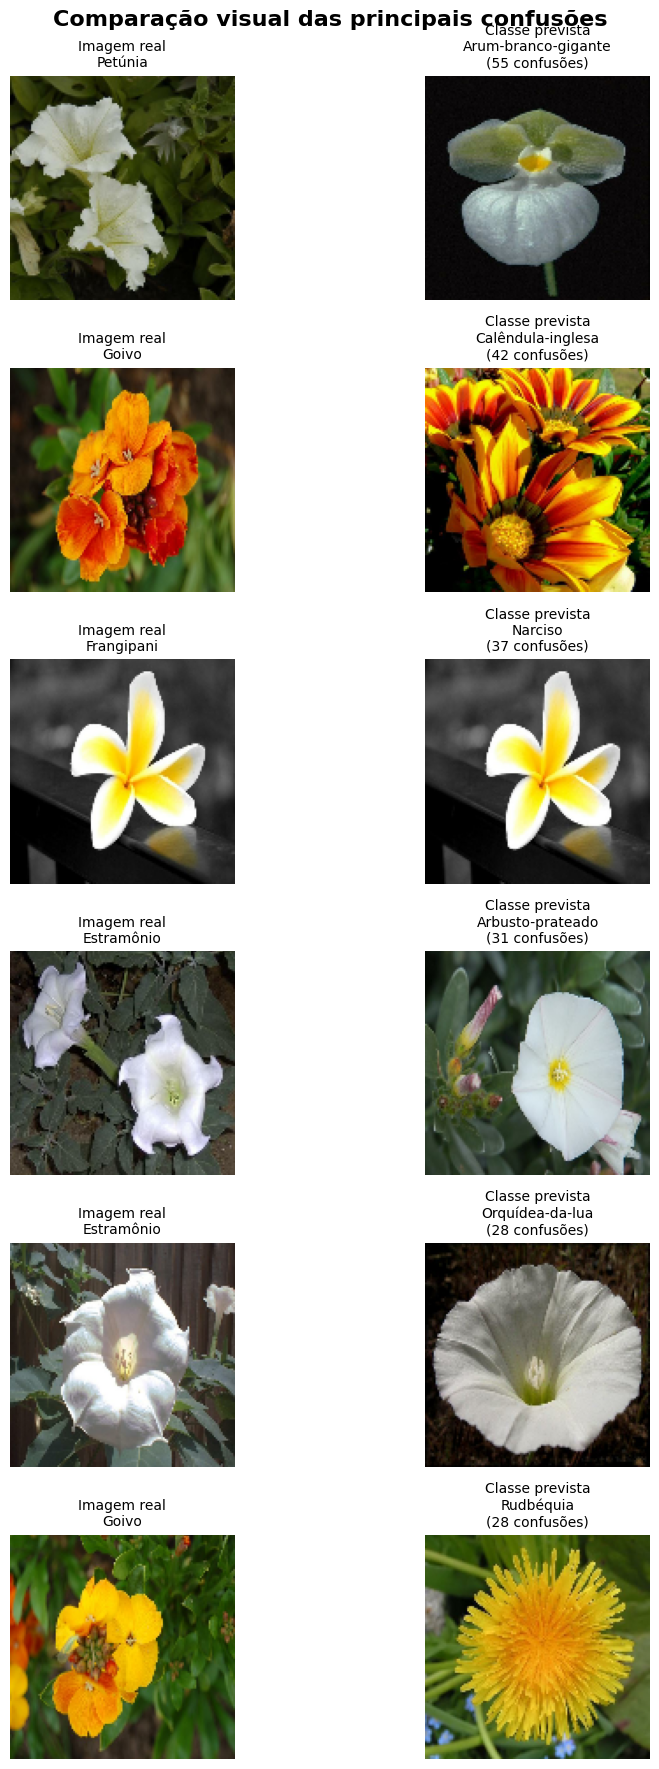

In [25]:
# 🌸 Comparação visual das principais confusões

principais_confusoes = confusoes[:6]

# Pares que queremos investigar
pares_interesse = {
    (classe_real, classe_prevista)
    for _, classe_real, classe_prevista in principais_confusoes
}

# Armazenará uma imagem real para cada confusão
imagens_confundidas = {}

# Armazenará uma imagem de referência para cada classe prevista
imagens_referencia = {}

# Percorrendo o conjunto de teste
for imagens, labels in dataset_teste:

    previsoes = modelo.predict(imagens, verbose=0)
    classes_previstas = np.argmax(previsoes, axis=1)

    for imagem, classe_real, classe_prevista in zip(
        imagens.numpy(),
        labels.numpy(),
        classes_previstas
    ):

        par = (int(classe_real), int(classe_prevista))

        # Guarda a primeira imagem que sofreu aquela confusão
        if par in pares_interesse and par not in imagens_confundidas:
            imagens_confundidas[par] = imagem

        # Guarda uma imagem representativa da classe prevista
        if classe_prevista not in imagens_referencia:
            imagens_referencia[int(classe_prevista)] = imagem


# Visualização
fig, axes = plt.subplots(
    len(principais_confusoes),
    2,
    figsize=(10, 18)
)

for i, (quantidade, classe_real, classe_prevista) in enumerate(
    principais_confusoes
):

    par = (classe_real, classe_prevista)

    # Imagem que foi classificada incorretamente
    imagem_real = imagens_confundidas[par]

    # Imagem da classe prevista
    imagem_referencia = imagens_referencia[classe_prevista]

    axes[i, 0].imshow(imagem_real)
    axes[i, 0].set_title(
        f"Imagem real\n"
        f"{nomes_portugues[classe_real]}",
        fontsize=10
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(imagem_referencia)
    axes[i, 1].set_title(
        f"Classe prevista\n"
        f"{nomes_portugues[classe_prevista]}\n"
        f"({quantidade} confusões)",
        fontsize=10
    )
    axes[i, 1].axis("off")


fig.suptitle(
    "Comparação visual das principais confusões",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 🧠 O que podemos observar?

As principais confusões ocorrem entre categorias com **características visuais semelhantes**, como cor, formato e enquadramento.

Exemplos:
- **Frangipani → Narciso:** 37 vezes
- **Petúnia → Arum-branco-gigante:** 55 vezes
- **Goivo → Calêndula-inglesa:** 42 vezes

> 💡 Na visão computacional, o desafio não é apenas reconhecer uma flor, mas **diferenciar categorias visualmente semelhantes**.

## ❌ 16. Analisando os erros do modelo

Vamos visualizar algumas **classificações incorretas** para entender onde o modelo apresenta maior dificuldade.

> 💡 Os erros podem ocorrer quando as flores possuem **características visuais semelhantes**.

Quantidade de imagens classificadas incorretamente: 4957


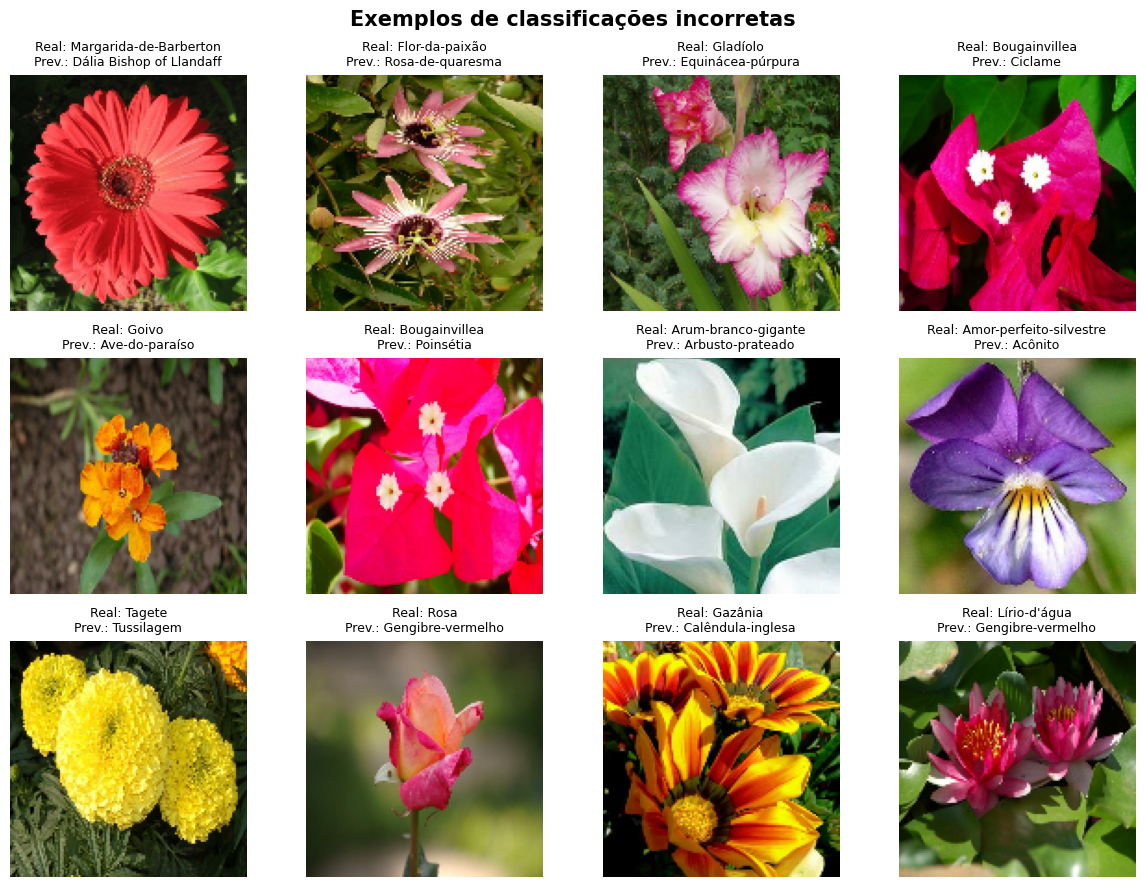

In [26]:
# ❌ Identificando e visualizando erros de classificação

erros = np.where(y_true != y_pred)[0]

print(f"Quantidade de imagens classificadas incorretamente: {len(erros)}")

# Quantidade de erros que serão exibidos
quantidade = min(12, len(erros))

# Índices dos erros que queremos visualizar
indices_erros = set(erros[:quantidade])

# Dicionário para armazenar somente as imagens necessárias
imagens_erros = {}

indice_global = 0

# Percorrendo o conjunto de teste apenas uma vez
for imagens, labels in dataset_teste:

    tamanho_lote = imagens.shape[0]

    for i in range(tamanho_lote):

        if indice_global in indices_erros:
            imagens_erros[indice_global] = imagens[i].numpy()

        indice_global += 1

        if len(imagens_erros) == quantidade:
            break

    if len(imagens_erros) == quantidade:
        break


# Visualizando os erros
plt.figure(figsize=(12, 9))

for i, indice in enumerate(erros[:quantidade]):

    imagem = imagens_erros[indice]

    plt.subplot(3, 4, i + 1)
    plt.imshow(imagem)

    plt.title(
        f"Real: {nomes_portugues[y_true[indice]]}\n"
        f"Prev.: {nomes_portugues[y_pred[indice]]}",
        fontsize=9
    )

    plt.axis("off")


plt.suptitle(
    "Exemplos de classificações incorretas",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 🔮 17. Inferência — Colocando a IA para trabalhar

Agora vamos testar o modelo em uma **imagem do conjunto de teste**.

A rede gera **102 probabilidades**, uma para cada categoria, e a maior será sua previsão.

> 🌸 **Qual é a espécie desta flor?**
>
> A previsão será comparada com a **classe real** da imagem.

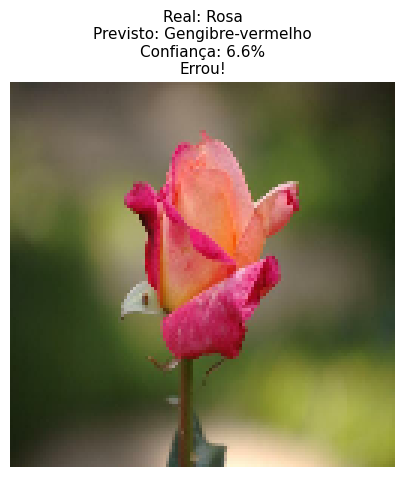

In [28]:
# 🔮 Realizando uma previsão

# Seleciona uma imagem do conjunto de teste
imagens_teste_lista = []
labels_teste_lista = []

for imagens, labels in dataset_teste:
    imagens_teste_lista.extend(imagens.numpy())
    labels_teste_lista.extend(labels.numpy())

# Escolhe uma imagem para testar
indice = 10

imagem = imagens_teste_lista[indice]
classe_real = labels_teste_lista[indice]

# Adiciona a dimensão do lote
imagem_modelo = np.expand_dims(imagem, axis=0)

# Realiza a previsão
previsoes = modelo.predict(imagem_modelo, verbose=0)[0]

# Identifica a classe com maior probabilidade
classe_prevista = np.argmax(previsoes)
confianca = previsoes[classe_prevista]

# Verifica se a previsão está correta
resultado = "Acertou!" if classe_real == classe_prevista else "Errou!"

# Exibe o resultado
plt.figure(figsize=(5, 5))

plt.imshow(imagem)

plt.title(
    f"Real: {nomes_portugues[classe_real]}\n"
    f"Previsto: {nomes_portugues[classe_prevista]}\n"
    f"Confiança: {confianca:.1%}\n"
    f"{resultado}",
    fontsize=11
)

plt.axis("off")
plt.show()

## 🔝 18. As 5 principais previsões

A rede neural produz uma probabilidade para cada uma das 102 classes.

Em vez de observar apenas a classe escolhida, podemos analisar as **5 categorias que receberam as maiores probabilidades**.

Essa abordagem permite entender melhor a decisão do modelo, principalmente quando a previsão final está incorreta.

In [29]:
# 🔝 Obtendo as 5 principais previsões

indices_top5 = np.argsort(previsoes)[-5:][::-1]

print("🔝 Top 5 previsões:")
print("-" * 50)

for posicao, classe in enumerate(indices_top5, start=1):
    print(
        f"{posicao}º | "
        f"{nomes_portugues[classe]} → "
        f"{previsoes[classe]:.1%}"
    )

🔝 Top 5 previsões:
--------------------------------------------------
1º | Gengibre-vermelho → 6.6%
2º | Bromélia → 6.4%
3º | Antúrio → 5.0%
4º | Hibisco → 4.8%
5º | Margarida-cobertor → 4.2%


## 📊 18.1 Visualizando as probabilidades

Para facilitar a interpretação, vamos representar graficamente as cinco classes mais prováveis.

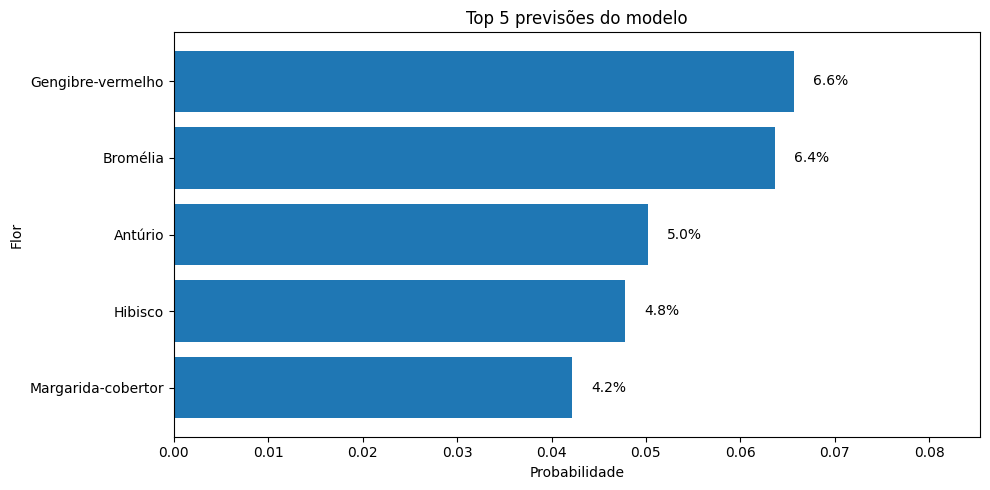

In [31]:
# 📊 Visualizando as probabilidades

nomes_top5 = [
    nomes_portugues[i]
    for i in indices_top5
]

valores_top5 = [
    previsoes[i]
    for i in indices_top5
]

plt.figure(figsize=(10, 5))

barras = plt.barh(
    nomes_top5[::-1],
    valores_top5[::-1]
)

plt.xlabel("Probabilidade")
plt.ylabel("Flor")
plt.title("Top 5 previsões do modelo")

plt.xlim(0, max(valores_top5) * 1.3)

# Exibe o percentual ao lado de cada barra
for barra, valor in zip(barras, valores_top5[::-1]):
    plt.text(
        valor + 0.002,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1%}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 🌐 19. Testando uma imagem da internet

Agora vamos testar o modelo em uma imagem externa ao conjunto Oxford Flowers 102.

Dessa forma, podemos observar como a rede se comporta diante de uma imagem que não fazia parte dos dados utilizados durante o treinamento, validação ou teste.

Para realizar a previsão, a imagem será:

1. baixada a partir de uma URL;
2. convertida para RGB;
3. redimensionada para **128 × 128 pixels**;
4. normalizada para valores entre **0 e 1**;
5. enviada para a rede neural.

> **Será que a IA consegue reconhecer uma flor que nunca viu durante o treinamento?** 🌸🤖

Status da requisição: 200
Tipo de conteúdo: image/jpeg
Imagem carregada com sucesso! 🌸
Tamanho original: (800, 800)


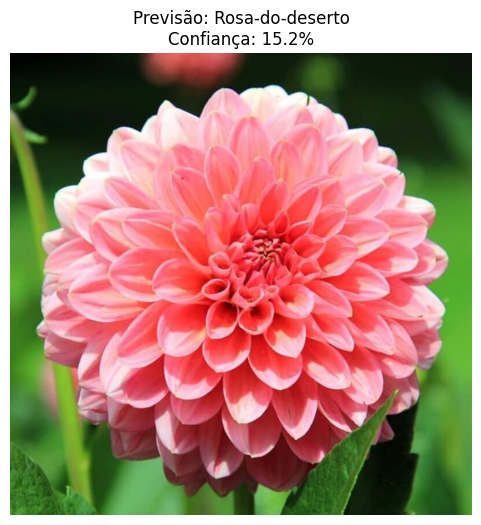

🔮 Top 5 previsões:
--------------------------------------------------
1º | Rosa-do-deserto → 15.2%
2º | Lírio-peruano → 11.1%
3º | Hippeastrum → 8.8%
4º | Ciclame → 8.7%
5º | Bromélia → 6.6%


In [37]:
# 🌐 Classificando uma imagem da internet

import requests
from PIL import Image
from io import BytesIO

# URL da imagem
url_imagem = "https://florescoloridas.com.br/wp-content/uploads/2022/03/flor-dalia-800x800.jpg"

# Simulando um navegador para evitar bloqueios simples
cabecalhos = {
    "User-Agent": "Mozilla/5.0"
}

resposta = requests.get(
    url_imagem,
    headers=cabecalhos,
    timeout=15
)

print("Status da requisição:", resposta.status_code)
print("Tipo de conteúdo:", resposta.headers.get("Content-Type"))

# Verificando se realmente recebemos uma imagem
resposta.raise_for_status()

if not resposta.headers.get("Content-Type", "").startswith("image"):
    raise ValueError("A URL não retornou uma imagem.")

# Abrindo a imagem
imagem_original = Image.open(
    BytesIO(resposta.content)
).convert("RGB")

print("Imagem carregada com sucesso! 🌸")
print("Tamanho original:", imagem_original.size)

# Preparando a imagem para o modelo
imagem_preparada = imagem_original.resize(IMG_SIZE)

imagem_array = np.array(
    imagem_preparada,
    dtype=np.float32
) / 255.0

# Adicionando a dimensão do lote
imagem_modelo = np.expand_dims(imagem_array, axis=0)

# Realizando a previsão
previsoes_internet = modelo.predict(
    imagem_modelo,
    verbose=0
)[0]

# Identificando as 5 maiores probabilidades
indices_top5_internet = np.argsort(
    previsoes_internet
)[-5:][::-1]

classe_prevista_internet = indices_top5_internet[0]
confianca_internet = previsoes_internet[
    classe_prevista_internet
]

# Exibindo a imagem e o resultado
plt.figure(figsize=(6, 6))
plt.imshow(imagem_original)

plt.title(
    f"Previsão: {nomes_portugues[classe_prevista_internet]}\n"
    f"Confiança: {confianca_internet:.1%}",
    fontsize=12
)

plt.axis("off")
plt.show()

print("🔮 Top 5 previsões:")
print("-" * 50)

for posicao, classe in enumerate(
    indices_top5_internet,
    start=1
):
    print(
        f"{posicao}º | "
        f"{nomes_portugues[classe]} → "
        f"{previsoes_internet[classe]:.1%}"
    )

# 🌸 20. Conclusão

Neste projeto, desenvolvemos uma **IA para classificação de imagens de flores**, utilizando o **Oxford Flowers 102** e uma **Rede Neural Convolucional (CNN)**.

O pipeline envolveu:

**📊 Dados → 🧹 Pré-processamento → 🔄 Data Augmentation → 🧠 CNN → 🚀 Treinamento → 🧪 Teste → 🔮 Inferência**

Com **102 categorias**, o modelo alcançou **19,39% de acurácia no teste**, resultado superior ao acaso (**0,98%**).

A análise das curvas e da matriz de confusão mostrou **limitações e sinais de overfitting**, enquanto os testes com imagens externas demonstraram a dificuldade do modelo em generalizar para novos exemplos.

> 🌱 **Conclusão:** a IA aprende **padrões visuais presentes nos dados**, mas sua capacidade de classificação depende da qualidade dos dados, do treinamento e da semelhança entre os exemplos.

### 🤖 Resultado final

**🎯 Problema:** classificação de flores  
**📚 Dataset:** Oxford Flowers 102  
**🌸 Classes:** 102  
**🧠 Modelo:** CNN  
**🔄 Técnica:** Data Augmentation  
**📊 Acurácia:** 19,39%  
**🔮 Saída:** classe prevista + probabilidades

> 🌸 **Uma imagem. 102 possibilidades. A IA aprende padrões e tenta descobrir a resposta.** 🤖